# Fit Genius — Squat Dataset Exploration

**Build-order step 1.** Understand the squat data and its label distributions before any training.

Two distinct squat sources ship with the project:

| Source | File | Representation | Nature |
|---|---|---|---|
| **A** | `CSV_files/coords_SQ_C.csv` | raw 132-dim MediaPipe landmarks + combined phase/form `class` | real footage |
| **B** | `squat_dataset/squat_features_augmented.csv` | 12 engineered angles/metrics + numeric `label` | **synthetic (augmented)** |

These are *not* interchangeable — A matches the LSTM pipeline in `CLAUDE.md` (raw landmarks → angles),
B is a balanced, feature-engineered set derived only from correct-form clips.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Locate the repo root (the folder that contains `backend/`) regardless of cwd.
root = Path.cwd()
while not (root / "backend").exists() and root != root.parent:
    root = root.parent
DATA = root / "backend" / "training" / "data"
FIGS = (root / "notebooks" / "figures"); FIGS.mkdir(parents=True, exist_ok=True)
print("repo root :", root)
print("data dir  :", DATA)

LANDMARK_COLS = [f"{a}{i}" for i in range(1, 34) for a in ("x", "y", "z", "v")]
print("expected landmark feature count:", len(LANDMARK_COLS), "(33 landmarks x [x,y,z,v])")

repo root : D:\Fit_genius
data dir  : D:\Fit_genius\backend\training\data
expected landmark feature count: 132 (33 landmarks x [x,y,z,v])


## Source A — raw MediaPipe landmarks (`coords_SQ_C.csv`)

In [2]:
# --- Source A: raw MediaPipe landmark coordinates (real footage) ---
sq = pd.read_csv(DATA / "CSV_files" / "coords_SQ_C.csv")
print("coords_SQ_C.csv  shape:", sq.shape)
print("label column     :", sq.columns[0])
print("feature columns  :", sq.shape[1] - 1, "(should be 132 landmark features)")
print("null cells       :", int(sq.isnull().sum().sum()))
sq.head(3)

coords_SQ_C.csv  shape: (1303, 133)
label column     : class
feature columns  : 132 (should be 132 landmark features)
null cells       : 0


,class,x1,y1,z1,v1,x2,y2,z2,v2,x3,...,z31,v31,x32,y32,z32,v32,x33,y33,z33,v33
0,up,0.304483,0.110352,-0.067141,0.999932,0.323109,0.088206,-0.117127,0.999941,0.329822,...,0.481228,0.540229,0.332018,0.928592,-0.490929,0.958294,0.390046,0.829371,0.356418,0.686186
1,up,0.304462,0.110373,-0.079666,0.999935,0.323082,0.088218,-0.129584,0.999943,0.329788,...,0.514681,0.539929,0.331529,0.928816,-0.482907,0.957735,0.389098,0.823751,0.393606,0.686986
2,up,0.303599,0.110326,-0.073520,0.999945,0.321818,0.088189,-0.122307,0.999949,0.328704,...,0.461899,0.532346,0.330180,0.928909,-0.504433,0.956508,0.388309,0.826984,0.330844,0.683564


### Class distribution
Each `class` value bundles the **phase** (up/down) with a **form** tag.

class
up              522
down_deep       349
down            234
down_forward    198

total frames: 1303


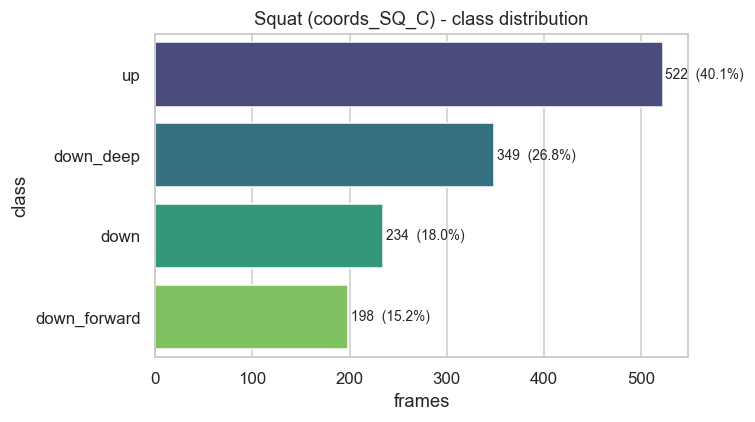

In [3]:
# Class distribution -- each class encodes PHASE + FORM together
counts = sq["class"].value_counts()
print(counts.to_string())
print("\ntotal frames:", len(sq))

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="viridis")
for i, v in enumerate(counts.values):
    ax.text(v + 3, i, f"{v}  ({v/len(sq)*100:.1f}%)", va="center", fontsize=9)
ax.set(title="Squat (coords_SQ_C) - class distribution", xlabel="frames", ylabel="class")
plt.tight_layout(); plt.savefig(FIGS / "squat_raw_class_dist.png"); plt.show()

### Phase vs. form breakdown

PHASE balance:
phase
down    781
up      522
Name: count, dtype: int64 

FORM tag balance:
form
correct    756
deep       349
forward    198
Name: count, dtype: int64


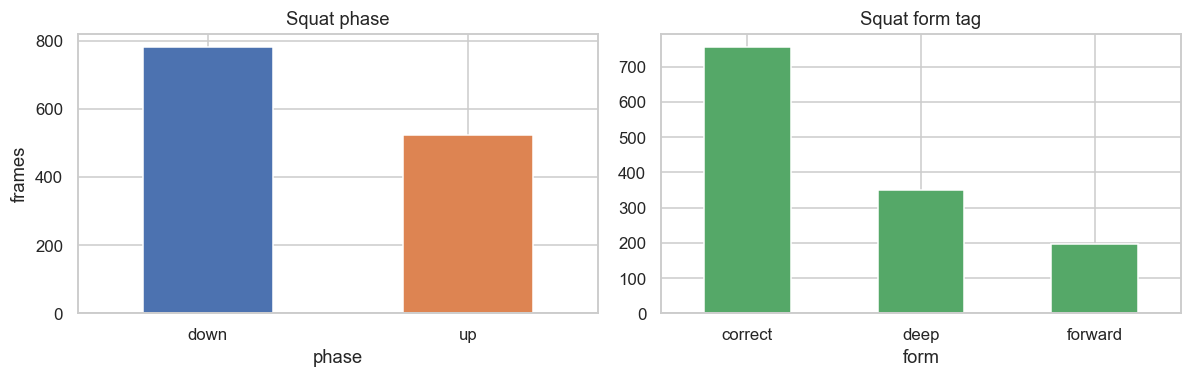

In [4]:
# Decompose the combined class into PHASE (up/down) + FORM tag
def phase_of(c):  return "up" if c.startswith("up") else "down"
def form_of(c):
    parts = c.split("_", 1)
    return "correct" if len(parts) == 1 else parts[1]

sq["phase"] = sq["class"].map(phase_of)
sq["form"]  = sq["class"].map(form_of)

print("PHASE balance:");        print(sq["phase"].value_counts(), "\n")
print("FORM tag balance:");     print(sq["form"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
sq["phase"].value_counts().plot.bar(ax=axes[0], color=["#4c72b0", "#dd8452"], rot=0)
axes[0].set(title="Squat phase", ylabel="frames")
sq["form"].value_counts().plot.bar(ax=axes[1], color="#55a868", rot=0)
axes[1].set(title="Squat form tag")
plt.tight_layout(); plt.savefig(FIGS / "squat_raw_phase_form.png"); plt.show()

### Landmark quality check
Low visibility means MediaPipe was unsure — useful to know before windowing.

count    1303.000
mean        0.780
std         0.059
min         0.673
25%         0.725
50%         0.782
75%         0.842
max         0.878
Name: mean_visibility, dtype: float64


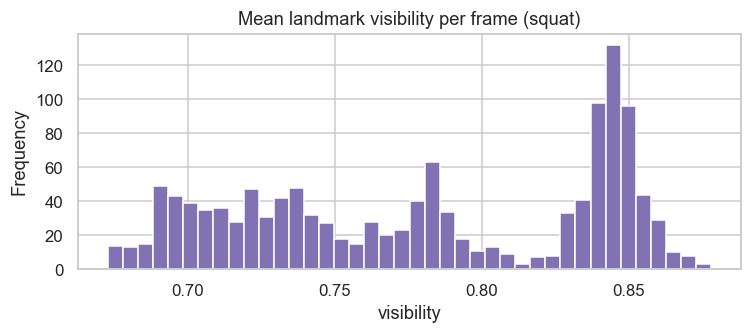

In [5]:
# Quick landmark-quality sanity check: mean visibility per frame
vis_cols = [c for c in sq.columns if c.startswith("v")]
sq["mean_visibility"] = sq[vis_cols].mean(axis=1)
print(sq["mean_visibility"].describe().round(3))
ax = sq["mean_visibility"].plot.hist(bins=40, figsize=(7, 3.2), color="#8172b3")
ax.set(title="Mean landmark visibility per frame (squat)", xlabel="visibility")
plt.tight_layout(); plt.savefig(FIGS / "squat_visibility.png"); plt.show()

## Source B — augmented engineered features (`squat_features_augmented.csv`)

⚠️ This file holds **computed angles**, not raw landmarks, and the labels are perfectly balanced —
a strong sign it was **synthetically augmented** from correct-form videos.

In [6]:
# --- Source B: pre-engineered features, AUGMENTED (synthetic) ---
aug = pd.read_csv(DATA / "squat_dataset" / "squat_features_augmented.csv")
print("squat_features_augmented.csv  shape:", aug.shape)
print("\ncolumns:", list(aug.columns))
print("\nNOTE: these are computed ANGLES/metrics, NOT raw 132-dim landmarks.")
aug.head(3)

squat_features_augmented.csv  shape: (47442, 15)

columns: ['left_knee_angle', 'right_knee_angle', 'left_hip_angle', 'right_hip_angle', 'left_ankle_angle', 'right_ankle_angle', 'spine_angle', 'torso_lean', 'left_knee_lateral', 'right_knee_lateral', 'symmetry_score', 'hip_depth', 'video_file', 'frame', 'label']

NOTE: these are computed ANGLES/metrics, NOT raw 132-dim landmarks.


,left_knee_angle,right_knee_angle,left_hip_angle,right_hip_angle,left_ankle_angle,right_ankle_angle,spine_angle,torso_lean,left_knee_lateral,right_knee_lateral,symmetry_score,hip_depth,video_file,frame,label
0,120.254411,102.110289,149.682786,141.059426,77.30243,70.434401,149.682786,95.286652,0.077956,0.090834,26.767481,0.444815,co1.mp4,0,0
1,132.223949,116.930256,164.205496,146.066398,77.30243,70.434401,149.682786,95.286652,0.077956,0.090834,26.767481,0.444815,co1.mp4,0,1
2,120.254411,102.110289,149.682786,141.059426,77.30243,70.434401,139.120795,108.975838,0.077956,0.090834,26.767481,0.444815,co1.mp4,0,2


### Label distribution

label counts (numeric 0-5):
label
0    7907
1    7907
2    7907
3    7907
4    7907
5    7907

-> perfectly balanced: True ( 7907 each ) -- a hallmark of synthetic augmentation
source videos: 15 clips, all 'co' (correct-form) recordings: ['co1.mp4', 'co10.mp4', 'co11.mp4', 'co12.mp4', 'co13.mp4'] ...


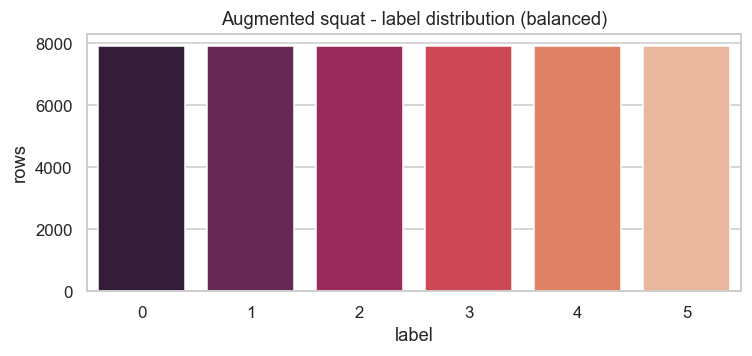

In [7]:
lc = aug["label"].value_counts().sort_index()
print("label counts (numeric 0-5):"); print(lc.to_string())
print("\n-> perfectly balanced:", lc.nunique() == 1, "(", lc.iloc[0], "each ) -- a hallmark of synthetic augmentation")
print("source videos:", aug["video_file"].nunique(), "clips, all 'co' (correct-form) recordings:",
      sorted(aug['video_file'].unique())[:5], "...")

fig, ax = plt.subplots(figsize=(7, 3.4))
sns.barplot(x=lc.index.astype(str), y=lc.values, ax=ax, palette="rocket")
ax.set(title="Augmented squat - label distribution (balanced)", xlabel="label", ylabel="rows")
plt.tight_layout(); plt.savefig(FIGS / "squat_aug_label_dist.png"); plt.show()

### Decoding the numeric labels (0–5)

There is no label legend file, so we infer meaning from each label's feature signature.
Each label appears to perturb **one** feature group away from the correct baseline:

label                   0      1       2      3      4      5
left_knee_angle     67.33  84.83   67.33  52.29  67.33  67.37
right_knee_angle    64.56  82.05   64.56  49.60  64.56  64.44
left_hip_angle      86.52  96.53   86.52  86.52  86.52  86.57
right_hip_angle     86.29  96.29   86.29  86.29  86.29  86.32
left_ankle_angle    39.53  39.53   39.53  39.53  57.08  39.53
right_ankle_angle   38.86  38.86   38.86  38.86  56.42  38.86
spine_angle         86.52  86.52   76.48  86.52  86.52  86.52
torso_lean          97.91  97.91  110.39  97.91  97.91  97.91
left_knee_lateral    0.09   0.09    0.09   0.13   0.09   0.09
right_knee_lateral   0.08   0.08    0.08   0.12   0.08   0.08
symmetry_score      13.22  13.22   13.22  13.22  13.22  13.22
hip_depth            0.59   0.59    0.59   0.59   0.59   0.59


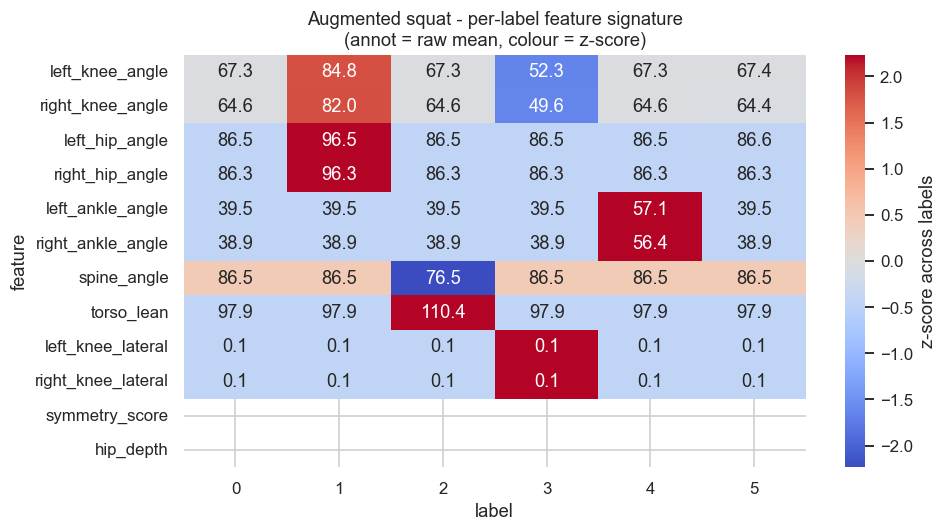

In [8]:
# Decode what each numeric label means by looking at per-label feature means.
feat = [c for c in aug.columns if c not in ("video_file", "frame", "label")]
means = aug.groupby("label")[feat].mean().round(2)
print(means.T)

# z-score each feature across labels to see which feature each label perturbs
z = (means - means.mean()) / means.std(ddof=0)
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(z.T, center=0, cmap="coolwarm", annot=means.T, fmt=".1f",
            cbar_kws={"label": "z-score across labels"}, ax=ax)
ax.set(title="Augmented squat - per-label feature signature\n(annot = raw mean, colour = z-score)",
       xlabel="label", ylabel="feature")
plt.tight_layout(); plt.savefig(FIGS / "squat_aug_label_signature.png"); plt.show()

### Read of the augmented set (interpretation)

- **0** baseline / correct
- **1** knee & hip angle more open → *insufficient depth (shallow squat)*
- **2** lower spine angle + higher torso lean → *excessive forward lean / back rounding*
- **3** knee angle very closed + higher knee-lateral → *too deep + knees caving*
- **4** raised ankle angle → *heels lifting / ankle issue*
- **5** ≈ baseline (near-identical to 0) → likely *noise-augmented correct*

`hip_depth` and `symmetry_score` are **constant across all labels** — they were never perturbed.
This is decent for prototyping but synthetic single-feature errors may not generalise to real lifters.

## Summary — squat

- **Source A (real, raw landmarks):** 1,303 frames, 4 classes, no nulls — matches the CLAUDE.md pipeline.
  Imbalanced (`up` ≈ 40%, `down_forward` ≈ 15%) and **no `frame`/`video` column**, so temporal
  windowing assumes rows are already in capture order within the file.
- **Source B (synthetic, engineered):** 47,442 rows, 6 perfectly-balanced labels from 15 correct-form
  clips — feature vectors only, not raw landmarks.
- **Open question:** which source drives the squat LSTM? They imply different model inputs.